# Eliminacion de valores faltantes

In [31]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import janitor as jn

from src.pandas_accessors import MissingMethods
from src.data_loader import load_all_datasets

datasets = load_all_datasets()

riskfactors =datasets['riskfactors']

<div style="background-color: rgba(255, 235, 59, 0.26); padding: 12px; border-radius: 6px;">

## Advertencia

La eliminación de valores faltantes **asume que los valores faltantes están perdidos completamente al azar (MCAR)**. En cualquier otro caso, realizar una eliminación de valores faltantes podrá ocasionar sesgos en los análisis y modelos subsecuentes.

</div>

In [4]:
riskfactors.shape

(245, 34)

## Pairwise deletion (Eliminacion por pares)

Se eliminan solo al momento de hacer calculos, aunque en realidad sigan estando dentro del dataset

Pandas lo hace por default ignora los valores faltantes por default

In [6]:
(
    riskfactors
    .weight_lbs
    .mean()
)

np.float64(174.26808510638298)

In [19]:
print("Tamaño del dataset original:", riskfactors.weight_lbs.size)
print("Número de valores no nulos en la columna weight_lbs:", riskfactors.weight_lbs.count())

Tamaño del dataset original: 245
Número de valores no nulos en la columna weight_lbs: 235


In [24]:
print(f"Media de la columna weight_lbs (incluyendo valores faltantes): { riskfactors.weight_lbs.mean( skipna=False)}")

print("Se obtiene un nan ya que la media no puede calcularse si hay valores faltantes en la columna weight_lbs.\n Para obtener la media de los valores no nulos, se puede utilizar el parámetro skipna=True.")

riskfactors.mean(numeric_only=True, skipna=False)

Media de la columna weight_lbs (incluyendo valores faltantes): nan
Se obtiene un nan ya que la media no puede calcularse si hay valores faltantes en la columna weight_lbs.
 Para obtener la media de los valores no nulos, se puede utilizar el parámetro skipna=True.


age                58.106122
bmi                      NaN
children            0.424490
health_physical     4.118367
health_mental       3.142857
dtype: float64

## Listwise Deletion or Complete Case (Eliminacion por lista o caso completo)

Si existe un valor faltante toda la fila que contenga este valor faltante sera eliminada

In [18]:
# En este caso se eliminara 10 filas de todo el dataset, ya que se eliminaran todas las filas que tengan un valor faltante en la columna weight_lbs

(
    riskfactors
    .dropna(
        subset=["weight_lbs"],
        how="any"
    )
    .shape
)

(235, 34)

### Con base en 2 o mas variables

In [27]:
(
    riskfactors
    .dropna(
        subset=["weight_lbs", "pregnant"],
        how="any"
    )
    .shape
)

(28, 34)

In [29]:
# Con el parametro how="all" se eliminan las filas que tengan valores faltantes en todas las columnas especificadas en subset. En este caso, se eliminarán las filas que tengan valores faltantes tanto en la columna weight_lbs como en la columna pregnant.

(
    riskfactors
    .dropna(
        subset=["weight_lbs", "pregnant"],
        how="all"
    )
    .shape
)

(237, 34)

## Representacion grafica tras la eliminacion de valores faltantes

<Axes: >

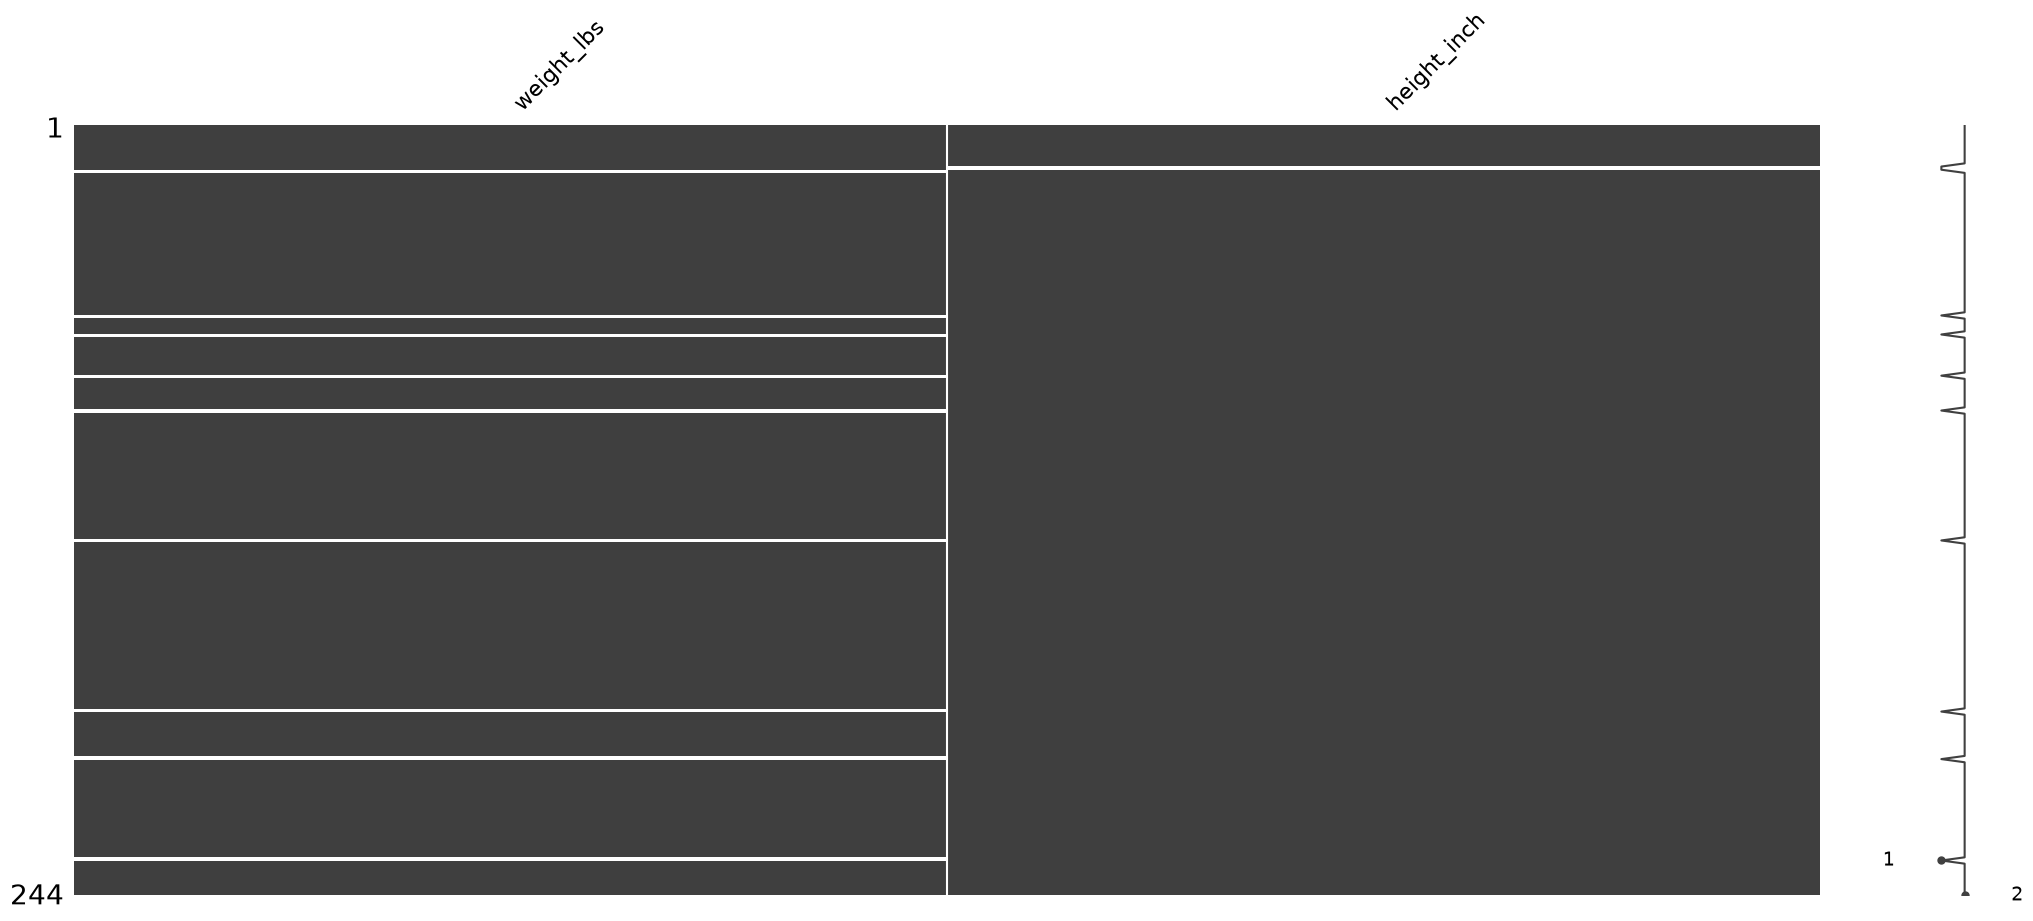

In [35]:
(
    riskfactors
    .dropna(
        subset=["weight_lbs", "height_inch"],
        how="all"
    )
    .select_columns(["weight_lbs", "height_inch"])
    .pipe(
        msno.matrix
    )
)